# Sales Forecasting System
**Cognevance Technologies | Level 2 – Intermediate Project**

This notebook loads the cleaned sales dataset, performs basic validation and exploratory analysis, trains and evaluates a Linear Regression model using a chronological holdout, forecasts the next three months, and exports forecast results.

**Run all cells from top to bottom.** In Google Colab, upload `Sales_Forecasting_Dataset.xlsx` when prompted.

## 1. Import libraries and load the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Upload the Excel dataset in Google Colab; otherwise enter a local file path.
try:
    from google.colab import files
    uploaded = files.upload()
    if not uploaded:
        raise ValueError("No file uploaded. Run this cell again and select Sales_Forecasting_Dataset.xlsx.")
    file_name = next(iter(uploaded.keys()))
except ImportError:
    file_name = input("Enter path to Sales_Forecasting_Dataset.xlsx: ").strip()

df = pd.read_excel(file_name, sheet_name="Cleaned_Data")
df.columns = df.columns.astype(str).str.strip()

print("Dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())
print("Columns:", df.columns.tolist())

Saving Sales_Forecasting_Dataset.xlsx to Sales_Forecasting_Dataset.xlsx
Dataset loaded successfully
Shape: (6000, 13)


,Order ID,Order Date,Customer Name,Product,Category,Region,City,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,ORD-02962,2025-01-01,Customer 0740,Laptop,Electronics,North,Jaipur,4,698.38,0.15,2374.49,369.92,UPI
1,ORD-01972,2025-01-01,Customer 0926,Laptop,Electronics,West,Ahmedabad,5,694.72,0.15,2952.56,500.66,Net Banking
2,ORD-01464,2025-01-01,Customer 0069,Laptop,Electronics,East,Patna,7,659.84,0.10,4156.99,723.12,Cash
3,ORD-04686,2025-01-01,Customer 0512,Monitor,Electronics,North,Delhi,5,219.49,0.05,1042.58,187.64,Debit Card
4,ORD-00697,2025-01-01,Customer 0395,Printer Paper,Office Supplies,East,Bhubaneswar,7,13.14,0.10,82.78,10.74,Net Banking


Columns: ['Order ID', 'Order Date', 'Customer Name', 'Product', 'Category', 'Region', 'City', 'Quantity', 'Unit Price', 'Discount', 'Sales', 'Profit', 'Payment Mode']


## 2. Data validation and preparation

In [2]:
required = ["Order Date", "Sales", "Profit", "Quantity", "Category", "Region", "Product", "Payment Mode"]
missing_columns = [c for c in required if c not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
for c in ["Sales", "Profit", "Quantity", "Unit Price", "Discount"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Exact duplicate rows:", int(df.duplicated().sum()))
print("\nMissing values by column:")
display(df.isna().sum().to_frame("Missing values"))

print("Rows with invalid/missing Order Date:", int(df["Order Date"].isna().sum()))
print("Rows with invalid/missing Sales:", int(df["Sales"].isna().sum()))
print("Rows with invalid/missing Quantity:", int(df["Quantity"].isna().sum()))

# Keep rows with a valid date and sales value for sales analysis.
df = df.dropna(subset=["Order Date", "Sales"]).copy()
df["Year"] = df["Order Date"].dt.year

print("\nAnalysis date range:", df["Order Date"].min().date(), "to", df["Order Date"].max().date())
print(f"Total Sales: {df['Sales'].sum():,.2f}")
print(f"Total Profit: {df['Profit'].sum():,.2f}")
print(f"Total Quantity: {df['Quantity'].sum():,.0f}")

Rows: 6000
Columns: 13
Exact duplicate rows: 0

Missing values by column:


,Missing values
Order ID,0
Order Date,0
Customer Name,0
Product,0
Category,0
Region,0
City,0
Quantity,0
Unit Price,0
Discount,0


Rows with invalid/missing Order Date: 0
Rows with invalid/missing Sales: 0
Rows with invalid/missing Quantity: 0

Analysis date range: 2025-01-01 to 2026-09-15
Total Sales: 2,942,914.89
Total Profit: 534,720.85
Total Quantity: 27,183


## 3. Exploratory data analysis

,Year,Sales
0,2025,1690346.27
1,2026,1252568.62


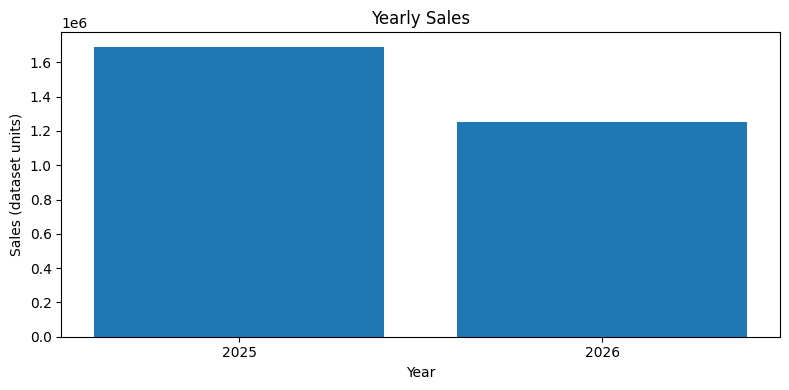

In [3]:
# Yearly sales
yearly_sales = df.groupby("Year", as_index=False)["Sales"].sum()
display(yearly_sales)

plt.figure(figsize=(8, 4))
plt.bar(yearly_sales["Year"].astype(str), yearly_sales["Sales"])
plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Sales (dataset units)")
plt.tight_layout()
plt.show()

,Category,Sales,Profit
0,Accessories,168696.71,31299.28
1,Electronics,1574328.38,285449.28
2,Furniture,1134984.84,206357.90
3,Office Supplies,64904.96,11614.39


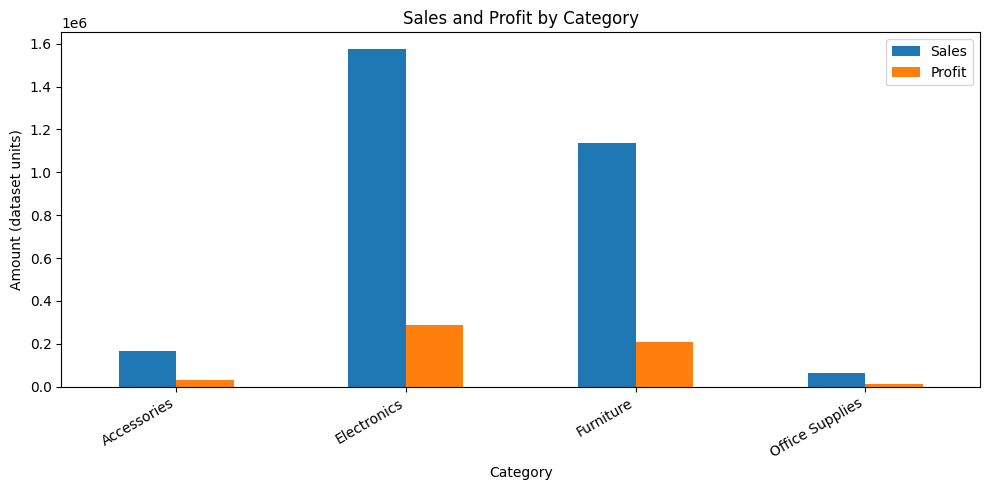

In [4]:
# Sales and profit by category
category_summary = df.groupby("Category", as_index=False)[["Sales", "Profit"]].sum()
display(category_summary)

category_summary.set_index("Category")[["Sales", "Profit"]].plot(kind="bar", figsize=(10, 5))
plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount (dataset units)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

,Region,Sales
2,South,742560.87
3,West,738400.70
1,North,732344.79
0,East,729608.53


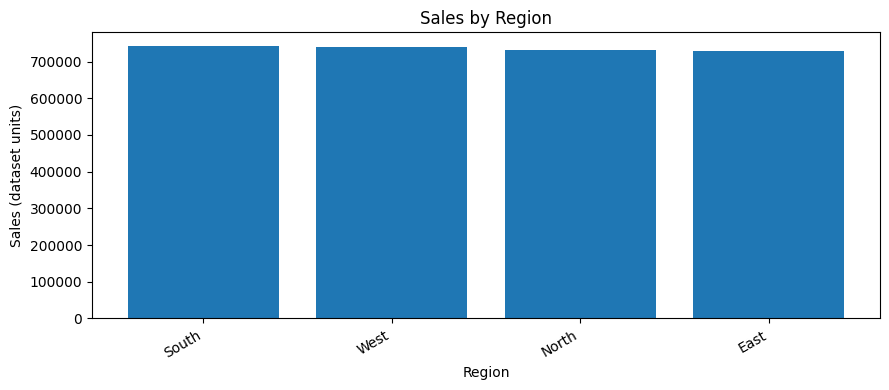

In [5]:
# Sales by region
region_sales = df.groupby("Region", as_index=False)["Sales"].sum().sort_values("Sales", ascending=False)
display(region_sales)

plt.figure(figsize=(9, 4))
plt.bar(region_sales["Region"].astype(str), region_sales["Sales"])
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales (dataset units)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

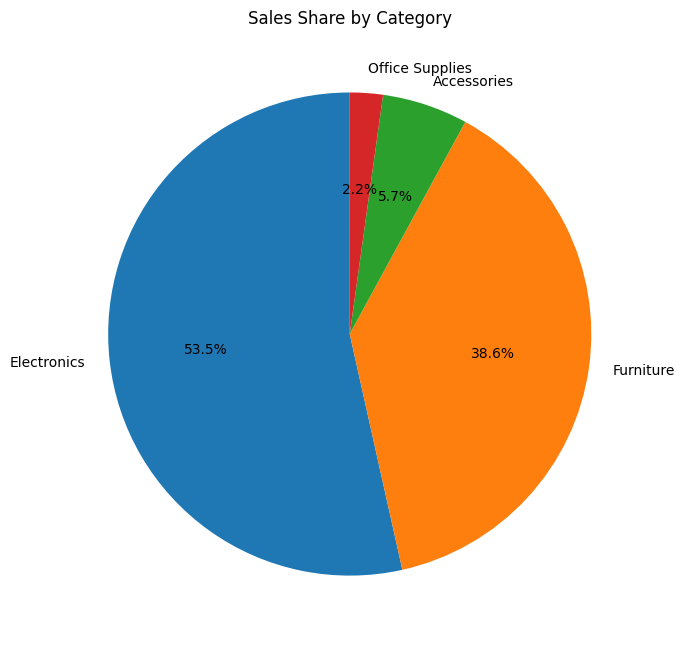

In [6]:
# Category sales share
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(7, 7))
plt.pie(category_sales, labels=category_sales.index, autopct="%1.1f%%", startangle=90)
plt.title("Sales Share by Category")
plt.tight_layout()
plt.show()

,Sales
Product,
Backpack,62334.54
Webcam,62467.99
Keyboard,70071.46
Headphones,137143.13
Bookshelf,197663.46
Office Chair,257116.19
Table,309812.78
Monitor,341937.49
Desk,370392.41


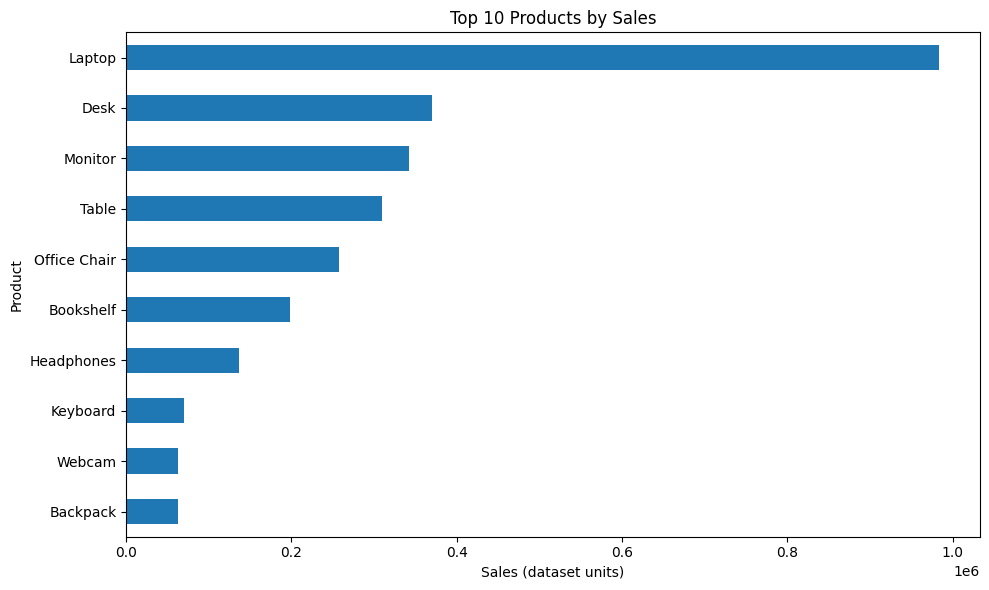

In [7]:
# Top 10 products by sales
top_products = df.groupby("Product")["Sales"].sum().nlargest(10).sort_values()
display(top_products.to_frame("Sales"))

plt.figure(figsize=(10, 6))
top_products.plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales (dataset units)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

,Payment Mode,Sales
4,UPI,624413.49
0,Cash,584184.59
2,Debit Card,584159.57
3,Net Banking,575398.62
1,Credit Card,574758.62


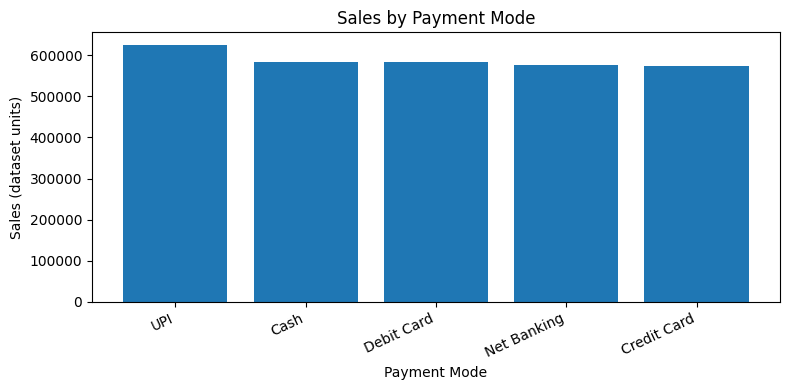

In [8]:
# Sales by payment mode
payment_sales = df.groupby("Payment Mode", as_index=False)["Sales"].sum().sort_values("Sales", ascending=False)
display(payment_sales)

plt.figure(figsize=(8, 4))
plt.bar(payment_sales["Payment Mode"].astype(str), payment_sales["Sales"])
plt.title("Sales by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Sales (dataset units)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 4. Aggregate sales by month

Number of monthly observations: 21
Average monthly sales: 140,138.80


,Month,Sales
0,2025-01-01,146494.14
1,2025-02-01,109028.59
2,2025-03-01,121396.20
3,2025-04-01,149541.98
4,2025-05-01,168839.23
5,2025-06-01,156179.51
6,2025-07-01,144328.01
7,2025-08-01,133482.58
8,2025-09-01,131922.39
9,2025-10-01,151490.89


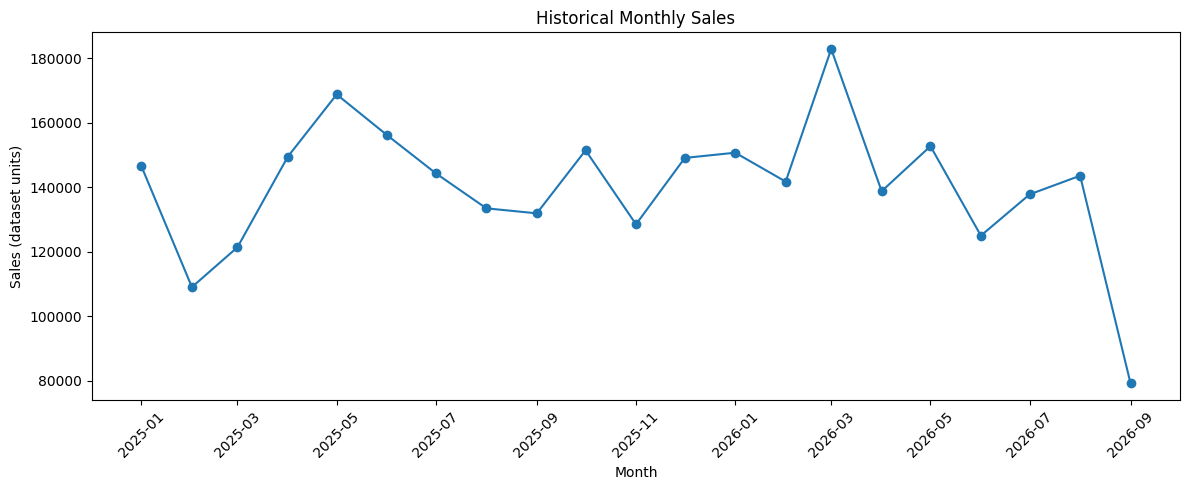

In [9]:
monthly = (
    df.set_index("Order Date")["Sales"]
      .resample("MS")
      .sum()
      .rename("Sales")
      .reset_index()
)
monthly.columns = ["Month", "Sales"]
monthly = monthly.sort_values("Month").reset_index(drop=True)

print("Number of monthly observations:", len(monthly))
print(f"Average monthly sales: {monthly['Sales'].mean():,.2f}")
display(monthly)

plt.figure(figsize=(12, 5))
plt.plot(monthly["Month"], monthly["Sales"], marker="o")
plt.title("Historical Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales (dataset units)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Train and evaluate Linear Regression

The last three observed months are held out as the test set. Earlier months are used for training to preserve time order. MAE and RMSE measure forecast error; lower values indicate smaller errors.

Training months: 18
Testing months: 3
MAE: 30,114.83
RMSE: 42,196.11


,Month,Sales,Predicted Sales,Absolute Error
18,2026-07-01,137816.80,149651.17,11834.37
19,2026-08-01,143601.68,150302.45,6700.77
20,2026-09-01,79144.38,150953.73,71809.35


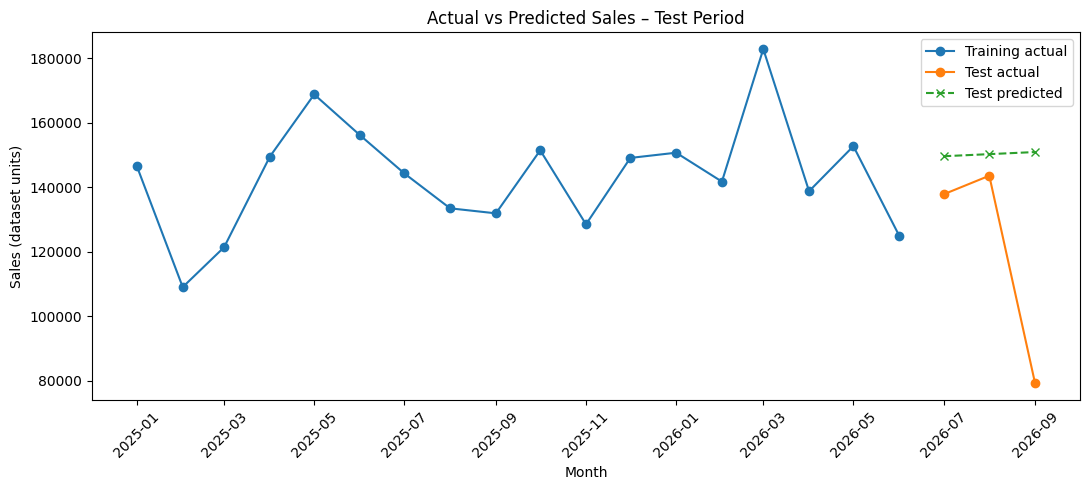

In [10]:
if len(monthly) <= 3:
    raise ValueError("At least 4 monthly observations are needed.")

test_size = 3
train = monthly.iloc[:-test_size].copy()
test = monthly.iloc[-test_size:].copy()

X_train = np.arange(len(train)).reshape(-1, 1)
y_train = train["Sales"].to_numpy()
X_test = np.arange(len(train), len(monthly)).reshape(-1, 1)
y_test = test["Sales"].to_numpy()

evaluation_model = LinearRegression()
evaluation_model.fit(X_train, y_train)
test_predictions = evaluation_model.predict(X_test)

mae = mean_absolute_error(y_test, test_predictions)
rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print(f"Training months: {len(train)}")
print(f"Testing months: {len(test)}")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

evaluation = test[["Month", "Sales"]].copy()
evaluation["Predicted Sales"] = test_predictions
evaluation["Absolute Error"] = np.abs(evaluation["Sales"] - evaluation["Predicted Sales"])
display(evaluation.round(2))

plt.figure(figsize=(11, 5))
plt.plot(train["Month"], train["Sales"], marker="o", label="Training actual")
plt.plot(test["Month"], test["Sales"], marker="o", label="Test actual")
plt.plot(test["Month"], test_predictions, marker="x", linestyle="--", label="Test predicted")
plt.title("Actual vs Predicted Sales – Test Period")
plt.xlabel("Month")
plt.ylabel("Sales (dataset units)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Forecast the next three months

Next three months forecast:


,Month,Forecast Sales
0,2026-10-01,134830.39
1,2026-11-01,134347.80
2,2026-12-01,133865.22


Linear trend coefficient (sales units per month): -482.58


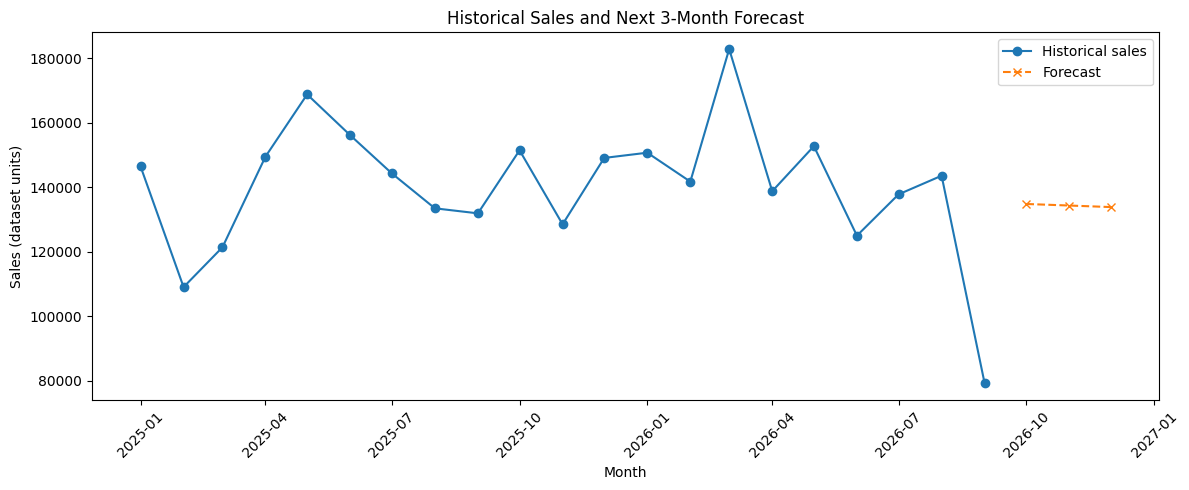

In [11]:
# Refit the final model on all available monthly history
X_all = np.arange(len(monthly)).reshape(-1, 1)
y_all = monthly["Sales"].to_numpy()

final_model = LinearRegression()
final_model.fit(X_all, y_all)

future_X = np.arange(len(monthly), len(monthly) + 3).reshape(-1, 1)
future_sales = final_model.predict(future_X)
future_months = pd.date_range(
    start=monthly["Month"].max() + pd.offsets.MonthBegin(1),
    periods=3,
    freq="MS"
)

forecast = pd.DataFrame({"Month": future_months, "Forecast Sales": future_sales})
print("Next three months forecast:")
display(forecast.round(2))
print(f"Linear trend coefficient (sales units per month): {final_model.coef_[0]:,.2f}")

plt.figure(figsize=(12, 5))
plt.plot(monthly["Month"], monthly["Sales"], marker="o", label="Historical sales")
plt.plot(forecast["Month"], forecast["Forecast Sales"], marker="x", linestyle="--", label="Forecast")
plt.title("Historical Sales and Next 3-Month Forecast")
plt.xlabel("Month")
plt.ylabel("Sales (dataset units)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Export forecast and evaluation results

In [12]:
evaluation.to_csv("sales_forecast_test_evaluation.csv", index=False)
forecast.to_csv("sales_forecast_next_3_months.csv", index=False)
print("Created: sales_forecast_test_evaluation.csv")
print("Created: sales_forecast_next_3_months.csv")

try:
    from google.colab import files
    files.download("sales_forecast_test_evaluation.csv")
    files.download("sales_forecast_next_3_months.csv")
except ImportError:
    print("CSV files saved in the current working directory.")

Created: sales_forecast_test_evaluation.csv
Created: sales_forecast_next_3_months.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Business interpretation and limitations

- Use the forecast as a planning baseline, not a guaranteed result.
- Review MAE and RMSE relative to typical monthly sales when judging forecast reliability.
- This is a simple linear trend model based on monthly observations. It does not explicitly model seasonality, holidays, promotions, price changes, stockouts, or external market conditions.
- Use the dashboard to investigate product, category, and regional patterns before making business decisions.
- Re-run the analysis when new sales data becomes available. For a stronger model, compare with seasonal/time-series methods and evaluate across multiple chronological test periods.

**Submission checklist:** Save this notebook after running all cells. Include this notebook, the source dataset, Power BI dashboard, business insights report, and a README in the GitHub repository.